In [1]:
# =============================================================================
# Vendor Performance Analysis
# Source: vendor_sales_summary table (EDA_data_preparation notebook se bani)
# Goal: Vendors ki profitability, sales performance aur pricing patterns samajhna
# =============================================================================

# ── 1. Libraries Import ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats

warnings.filterwarnings('ignore')  # unnecessary warnings band karo

In [2]:
# ── 2. Data Load ─────────────────────────────────────────────────────────────
# Pichli notebook mein banaya hua vendor_sales_summary table load karo
conn = sqlite3.connect('inventory.db')

df = pd.read_sql('SELECT * FROM vendor_sales_summary', conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


## Exploratory Data Analysis (EDA)

Previously, we examined the different tables in the database to identify key variables, understand their relationships, and determine which fields should be included in the final analysis.

In this phase of Exploratory Data Analysis (EDA), we analyze the resulting summary table to understand the distribution of each column. This helps us identify data patterns, detect anomalies, and ensure data quality before proceeding with further analysis.


In [3]:
# ── 3. Descriptive Statistics ────────────────────────────────────────────────
# Har numeric column ka distribution samjho — min, max, mean, std wagera
# Isse outliers aur data range ka andaaza hota hai
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


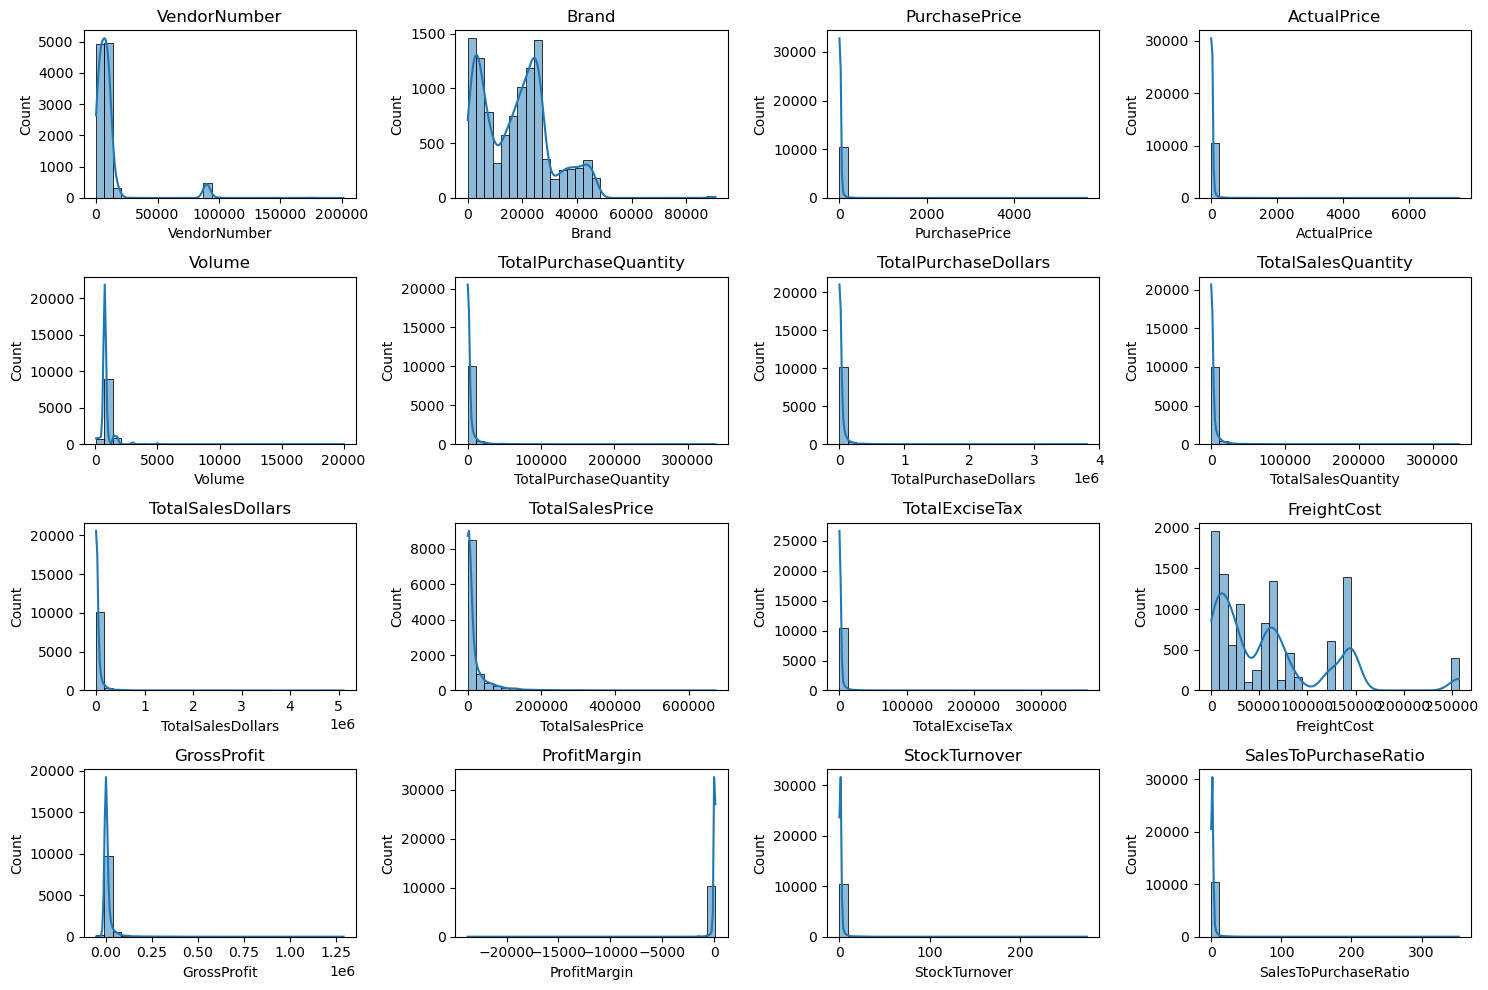

In [4]:
# ── 4. Distribution Plots ────────────────────────────────────────────────────
# har numeric column ka histogram + KDE plot
# isse pata chalta hai ki data skewed hai ya normal
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

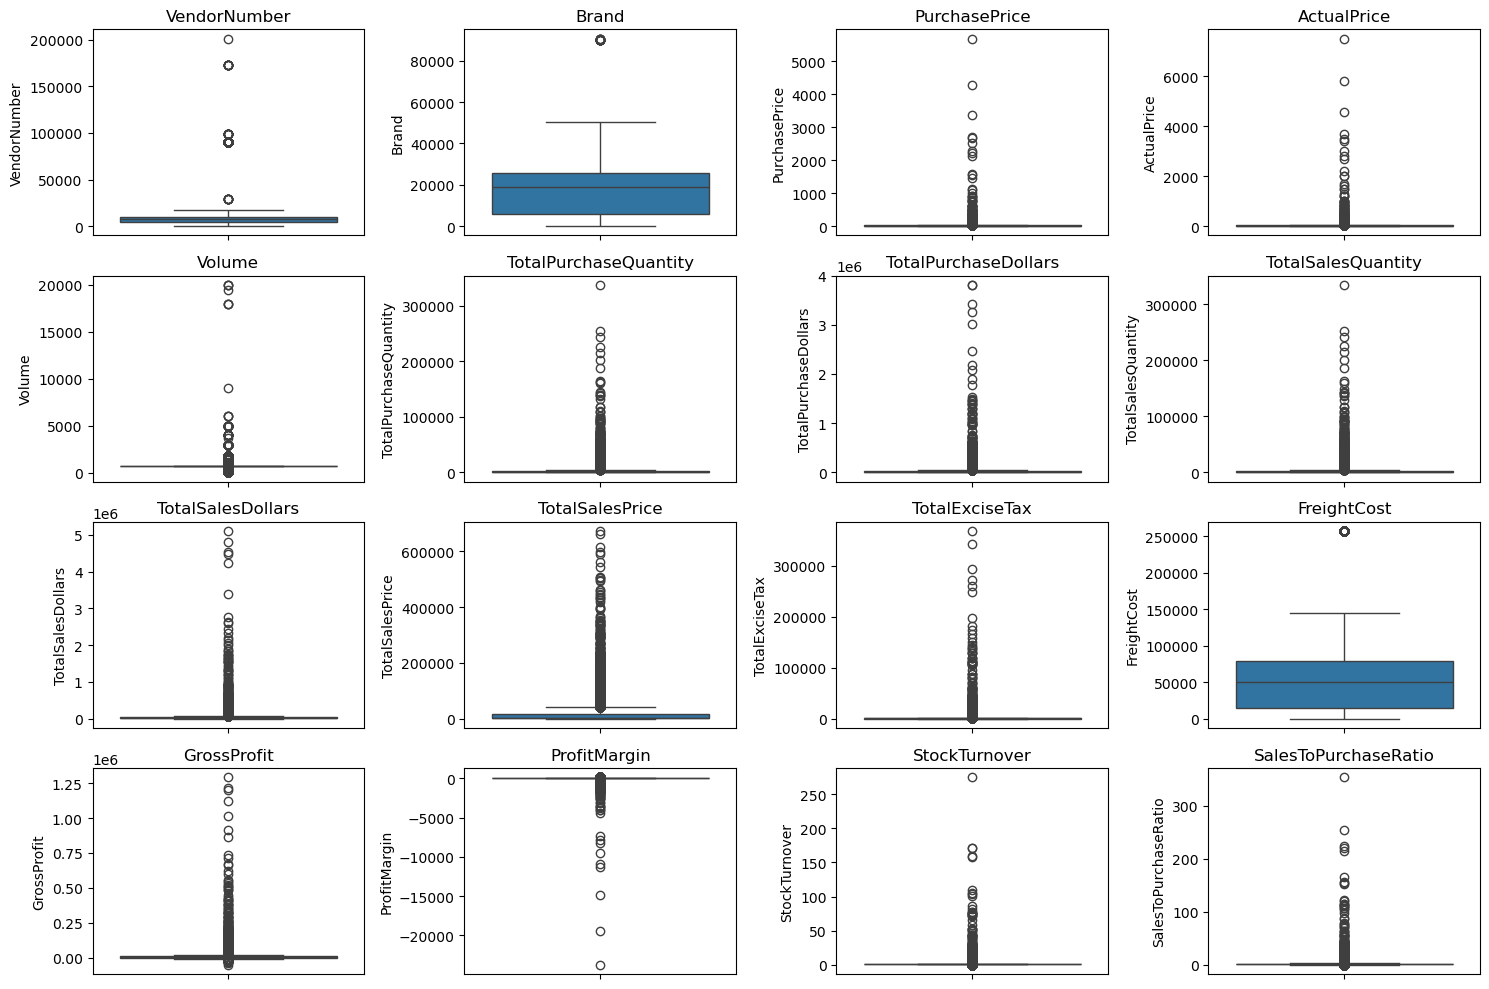

In [5]:
# ── 5. Outlier Detection — Box Plots ─────────────────────────────────────────
# box plot se outliers clearly dikhte hain — whisker ke bahar ke points outliers hain
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

 ### Summary Statistics Insights

#### Negative & Zero Values

* **Gross Profit:** The minimum value is **-52,002.78**, indicating losses. Some products or transactions may be selling at a loss due to high costs or discounts lower than the purchase price.

* **Profit Margin:** The minimum value is **-∞**, suggesting cases where revenue is zero or even lower than costs.

* **Total Sales Quantity & Sales Dollars:** Minimum values are **0**, meaning some products were purchased but never sold. These could represent **slow-moving or obsolete inventory**.

---

#### Outliers Indicated by High Standard Deviations

* **Purchase Price & Actual Price:** The maximum values (**5,681.81** and **7,499.99**) are significantly higher than the mean (**24.39** and **35.64**), indicating potential **premium or high-end products**.

* **Freight Cost:** Shows a large variation from **0.09 to 257,032.07**, suggesting possible **bulk shipments or logistics inefficiencies**.

* **Stock Turnover:** Ranges from **0 to 274.5**, implying that some products sell extremely quickly while others remain in inventory for long periods. A value greater than **1** indicates that sales are being fulfilled from previously stored inventory.


In [6]:
# ── 6. Data Filtering — Inconsistent Rows Hatao ──────────────────────────────
# sirf valid records rakho:
#   GrossProfit > 0      → loss mein biki items hata do
#   ProfitMargin > 0     → negative margin wali rows hata do
#   TotalSalesQuantity > 0 → jo bika hi nahi usse analysis mein mat lo
df = pd.read_sql_query("""
    SELECT * FROM vendor_sales_summary
    WHERE GrossProfit > 0
    AND ProfitMargin > 0
    AND TotalSalesQuantity > 0
""", conn)

In [7]:
# After filtering 
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


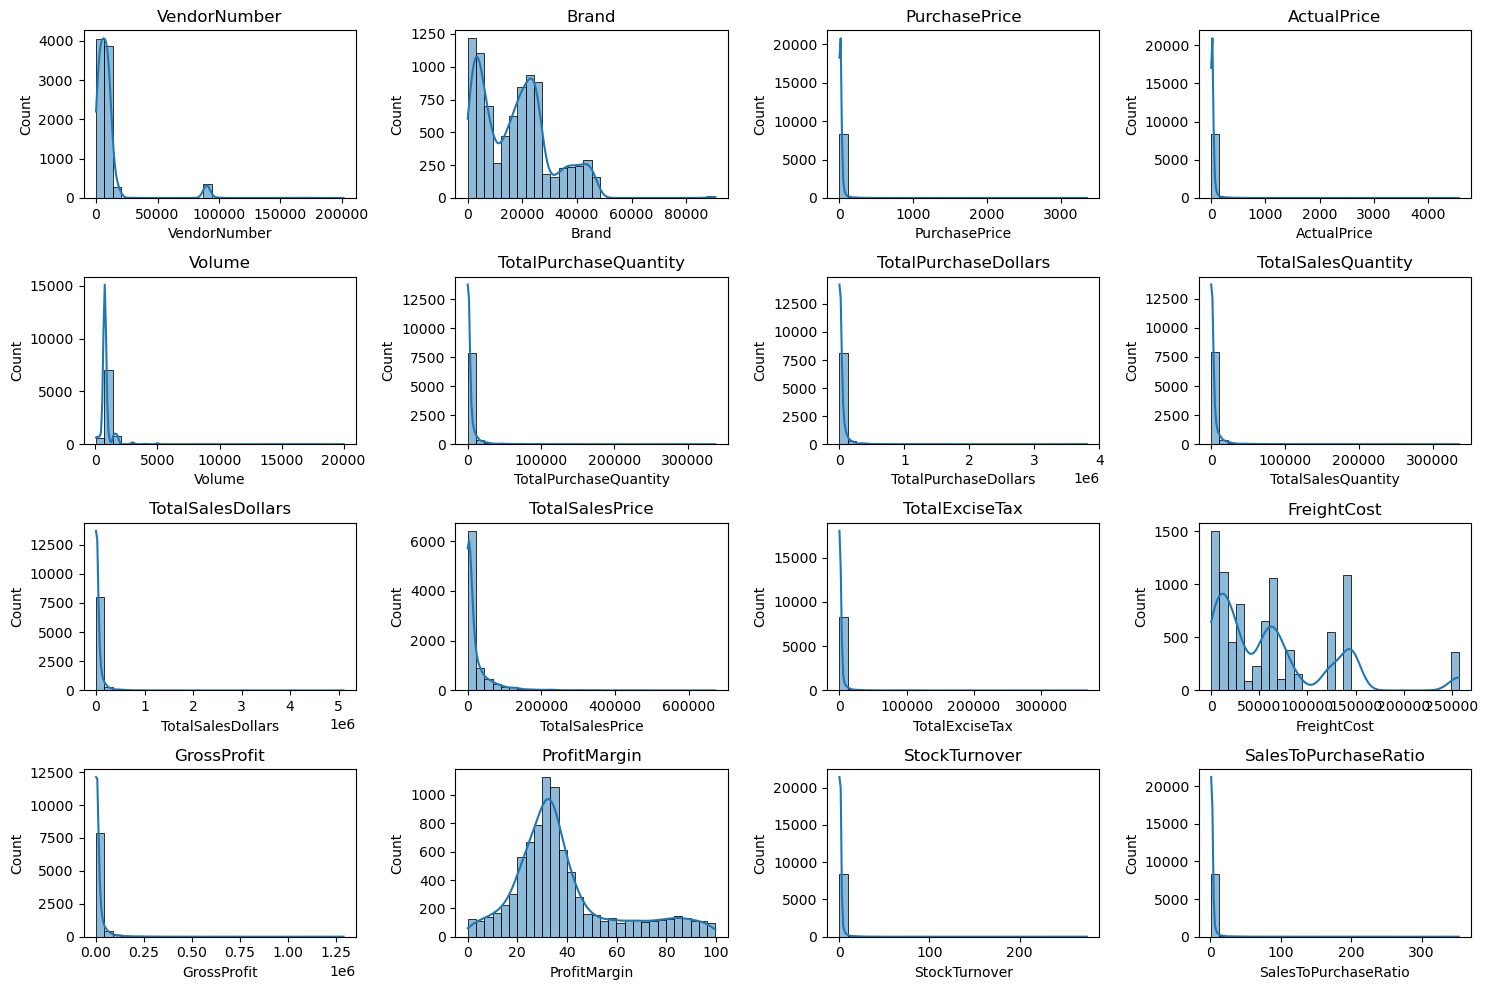

In [8]:
# ── 7. Cleaning ke Baad Distribution Check ───────────────────────────────────
# dobara distribution plots dekho — verify karo ki outliers/skewness kam hua ya nahi
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

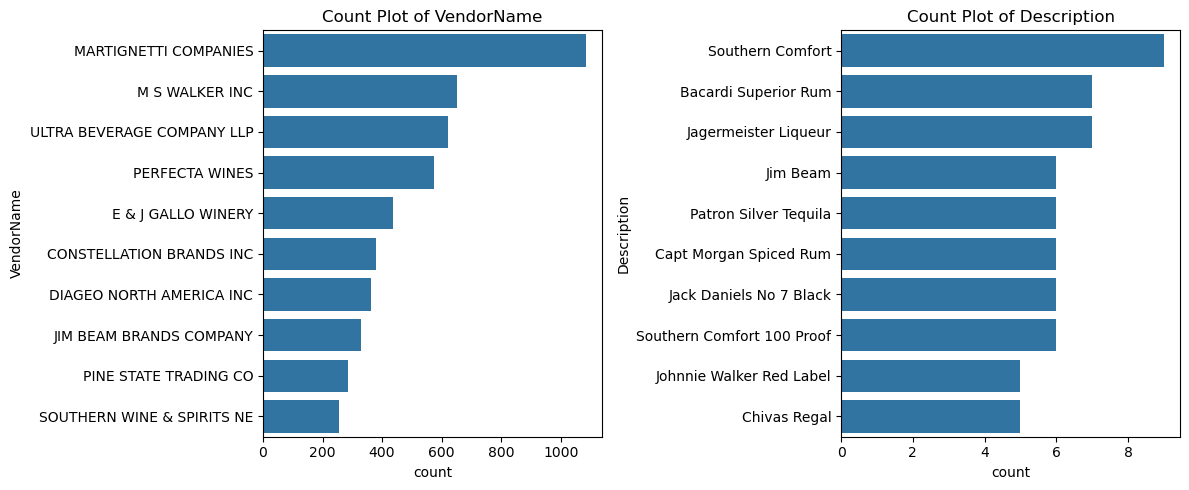

In [9]:
# ── 8. Categorical Columns — Count Plot ──────────────────────────────────────
# top 10 vendors aur brands kitni baar appear hote hain data mein
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

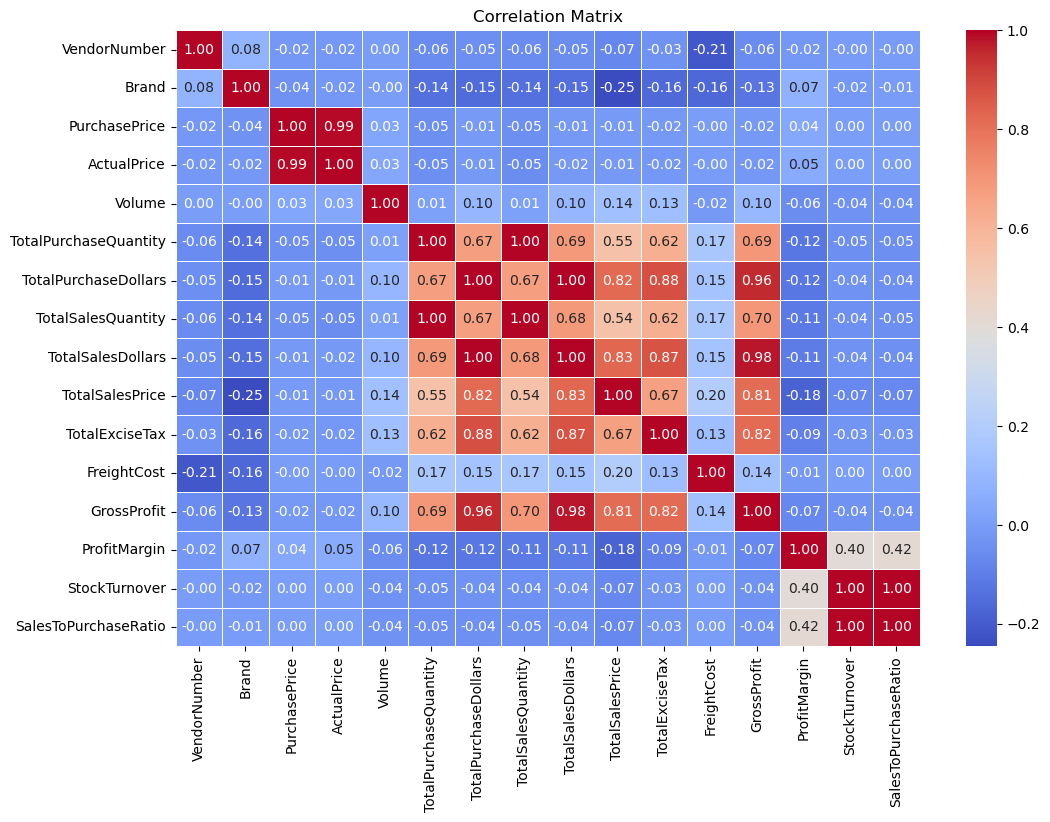

In [10]:
# ── 9. Correlation Heatmap ───────────────────────────────────────────────────
# columns ke beech relationship dekho
# +1 = strong positive, -1 = strong negative, 0 = koi relation nahi
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

### Correlation Insights

* **Purchase Price:** Shows weak correlations with **TotalSalesDollars (-0.012)** and **GrossProfit (-0.016)**. This suggests that variations in purchase price do not significantly influence overall sales revenue or profit.

* **Sales Quantity vs Purchase Quantity:** There is a strong positive correlation (**0.999**) between total purchase quantity and total sales quantity, indicating efficient inventory turnover.

* **Profit Margin vs Sales Price:** A negative correlation (**-0.179**) suggests that as sales price increases, profit margins tend to decrease. This may occur due to competitive pricing strategies or higher associated costs.

* **Stock Turnover:** Displays weak negative correlations with both **GrossProfit (-0.038)** and **ProfitMargin (-0.055)**, indicating that faster inventory turnover does not necessarily lead to higher profitability.


### DATA ANALYSIS

**Identify Brand that needs Promotional or pricing Adjustment which exhibit lower sales performance but higher profit margins** 

In [11]:
# ── 10. Brand Performance — Promotional Pricing ke liye Target Brands ────────
# brand level par total sales aur average profit margin aggregate karo
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()
brand_performance.head()

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182


In [12]:
# thresholds define karo:
# low sales  = bottom 15% revenue brands
# high margin = top 15% margin brands
low_sales_thresold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_thresold = brand_performance['ProfitMargin'].quantile(0.85)

In [13]:
print(low_sales_thresold)

560.299


In [14]:
print(high_margin_thresold)

64.97017552750113


In [15]:
# dono condition satisfy karne wale brands = promotional candidates
# matlab: ye already profitable hain, promote karo toh sales bhi badh sakti hai
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_thresold) &
    (brand_performance['ProfitMargin'] >= high_margin_thresold)
]
print('Brands with low sales but high Profit margins:')
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high Profit margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [16]:
# better visualization ke liye sirf low-sales brands rakho (< 10000)
# high sales brands plot mein saari jagah le lete hain
brand_performance = brand_performance[brand_performance['TotalSalesDollars'] < 10000]

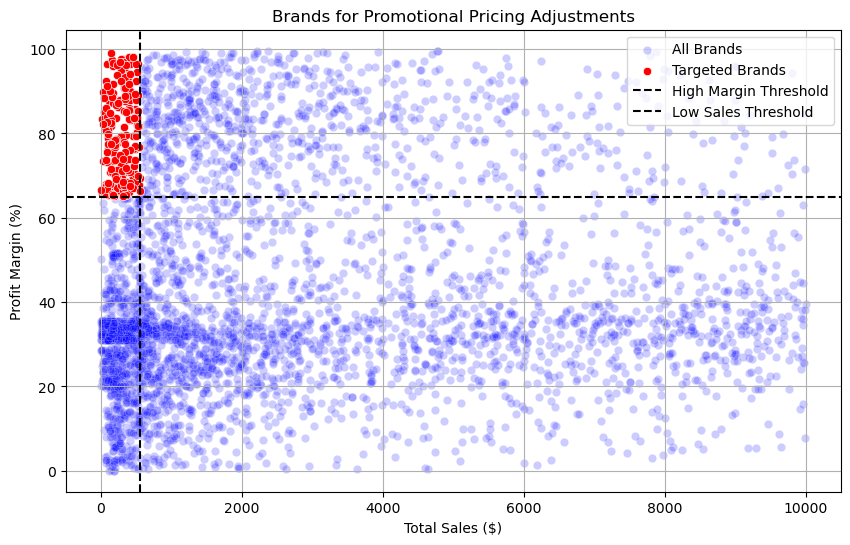

In [17]:
# scatter plot — all brands (blue) vs target brands (red)
# dashed lines = thresholds
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin',
                color='blue', label='All Brands', alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin',
                color='red', label='Targeted Brands')

plt.axhline(high_margin_thresold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_thresold, linestyle='--', color='black', label='Low Sales Threshold')

plt.xlabel("Total Sales ($)")
plt.ylabel('Profit Margin (%)')
plt.title('Brands for Promotional Pricing Adjustments')
plt.legend()
plt.grid(True)
plt.show()

**Which vendor and brands demonstrate the highest sales performance ?**

In [18]:
# ── 11. Helper Function — Dollar Values Format karo ──────────────────────────
# large numbers ko readable format mein dikhao (e.g., 1500000 → 1.50M)
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [19]:
# ── 12. Top 10 Vendors & Brands by Sales ─────────────────────────────────────
# sabse zyada revenue generate karne wale top 10 vendors aur brands
top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [20]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [21]:
# formatted display — M/K mein
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

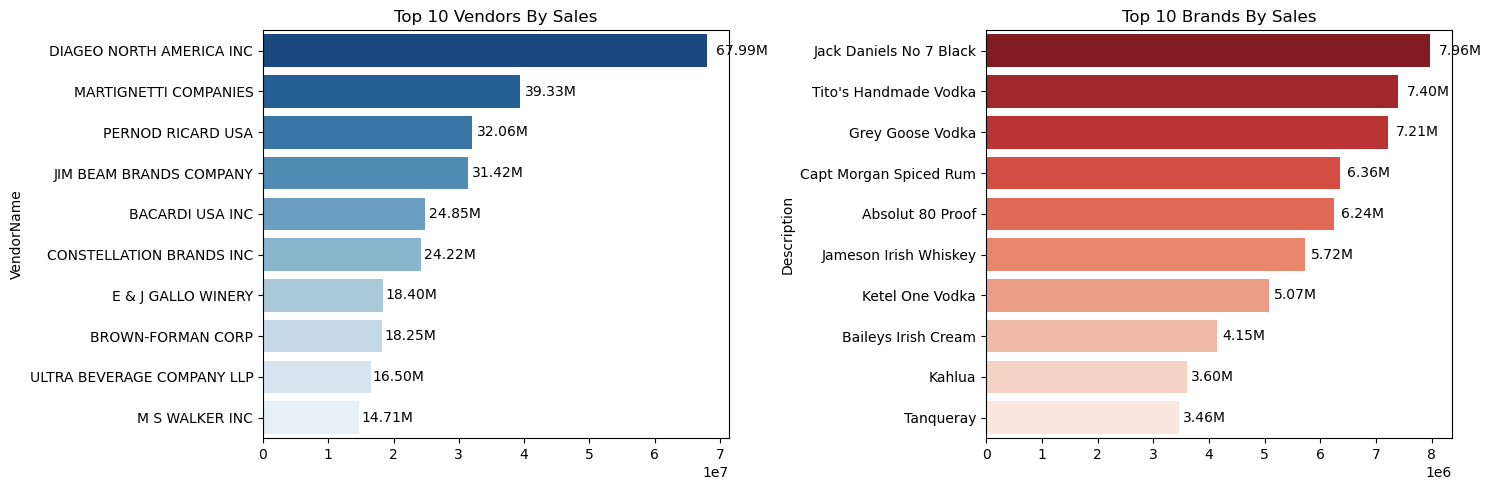

In [22]:
# bar chart — top 10 vendors aur brands side by side
plt.figure(figsize=(15, 5))

# left — top vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette='Blues_r')
plt.title('Top 10 Vendors By Sales')
for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )

# right — top brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette='Reds_r')
plt.title('Top 10 Brands By Sales')
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )

plt.tight_layout()
plt.show()

**WHICH VENDOR CONTRIBUTE THE MOST TO TOTAL PURCHASE DOLLARS**


In [23]:
# ── 13. Vendor Purchase Contribution ─────────────────────────────────────────
# vendor level par: total purchase, gross profit, total sales aggregate karo
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()
vendor_performance.shape

(119, 4)

In [24]:
# har vendor ka total procurement mein % contribution calculate karo
vendor_performance['PurchaseContribution%'] = (
    vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()
) * 100

# contribution ke hisaab se descending sort karo aur round karo
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending=False))

In [25]:
# top 10 vendors display karo — dollar values formatted string mein
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TopPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,TopPurchaseDollars
25,DIAGEO NORTH AMERICA INC,50097226.0,17.89M,67.99M,16.0,50.10M
57,MARTIGNETTI COMPANIES,25502096.0,13.83M,39.33M,8.0,25.50M
68,PERNOD RICARD USA,23851164.0,8.21M,32.06M,8.0,23.85M
46,JIM BEAM BRANDS COMPANY,23494304.0,7.93M,31.42M,8.0,23.49M
6,BACARDI USA INC,17432020.0,7.42M,24.85M,6.0,17.43M
20,CONSTELLATION BRANDS INC,15273708.0,8.95M,24.22M,5.0,15.27M
11,BROWN-FORMAN CORP,13238939.0,5.01M,18.25M,4.0,13.24M
30,E & J GALLO WINERY,12068539.0,6.33M,18.40M,4.0,12.07M
106,ULTRA BEVERAGE COMPANY LLP,11167082.0,5.34M,16.50M,4.0,11.17M
53,M S WALKER INC,9764313.0,4.94M,14.71M,3.0,9.76M


In [26]:
# cumulative contribution % calculate karo — Pareto analysis ke liye
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,TopPurchaseDollars,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50097226.0,17.89M,67.99M,16.0,50.10M,16.0
57,MARTIGNETTI COMPANIES,25502096.0,13.83M,39.33M,8.0,25.50M,24.0
68,PERNOD RICARD USA,23851164.0,8.21M,32.06M,8.0,23.85M,32.0
46,JIM BEAM BRANDS COMPANY,23494304.0,7.93M,31.42M,8.0,23.49M,40.0
6,BACARDI USA INC,17432020.0,7.42M,24.85M,6.0,17.43M,46.0
20,CONSTELLATION BRANDS INC,15273708.0,8.95M,24.22M,5.0,15.27M,51.0
11,BROWN-FORMAN CORP,13238939.0,5.01M,18.25M,4.0,13.24M,55.0
30,E & J GALLO WINERY,12068539.0,6.33M,18.40M,4.0,12.07M,59.0
106,ULTRA BEVERAGE COMPANY LLP,11167082.0,5.34M,16.50M,4.0,11.17M,63.0
53,M S WALKER INC,9764313.0,4.94M,14.71M,3.0,9.76M,66.0


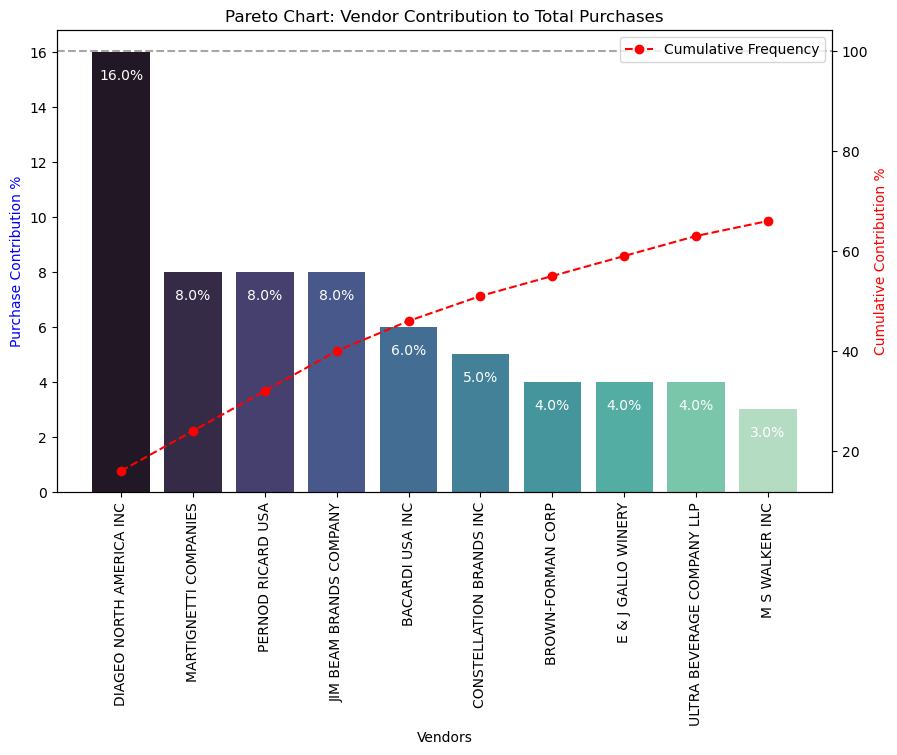

In [27]:
# ── 14. Pareto Chart ─────────────────────────────────────────────────────────
# bar = individual vendor contribution %
# red line = cumulative contribution % (Pareto line)
# agar top 20% vendors = 80% procurement → Pareto principle confirm
fig, ax1 = plt.subplots(figsize=(10, 6))

# bar plot — purchase contribution %
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'],
            palette='mako', ax=ax1)
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value) + '%', ha='center', fontsize=10, color='white')

# line plot — cumulative contribution % (second y-axis)
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'],
         color='red', marker='o', linestyle='dashed', label='Cumulative Frequency')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='grey', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

**HOW MUCH OF TOTAL PROCRUMENT IS DEPENDENT ON THE TOP VENDORS**

In [28]:
# top 10 vendors ka combined procurement share print karo
print(f"Total Purchase Contribution of Top 10 Vendors is {round(top_vendors['PurchaseContribution%'].sum(), 2)} %")

Total Purchase Contribution of Top 10 Vendors is 66.0 %


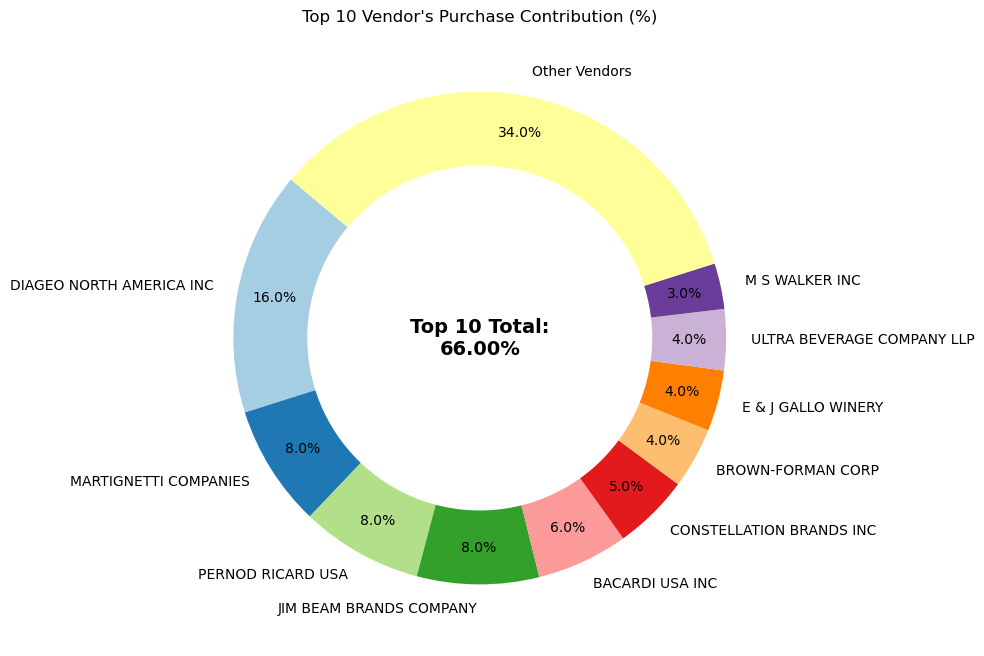

In [29]:
# ── 15. Donut Chart — Vendor Purchase Share ──────────────────────────────────
# top 10 vendors + "Other Vendors" category ka pie chart
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# baki saare vendors ko ek "Other Vendors" category mein daal do
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# donut chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# center mein white circle lagao — donut effect ke liye
center_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(center_circle)

# center mein total contribution annotation
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%",
         fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

**DOES PURCHASING IN BULK REDUCE UNIT PRICE, AND WHA IS THE OPTIMAL PURCHASE COLUME FOR COST SAVINGS**

In [30]:
# ── 16. Bulk Purchasing Impact ───────────────────────────────────────────────
# kya zyada bulk mein order karne se unit price kam hoti hai?

# unit purchase price = total spend / total units purchased
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [31]:
# purchase quantity ko 3 equal buckets mein divide karo (qcut = equal frequency bins)
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [32]:
# preview
df[['UnitPurchasePrice', 'OrderSize', 'TotalPurchaseQuantity']]

,UnitPurchasePrice,OrderSize,TotalPurchaseQuantity
0,26.27,Large,145080
1,23.19,Large,164038
2,18.24,Large,187407
3,16.17,Large,201682
4,21.89,Large,138109
...,...,...,...
8559,1.32,Small,2
8560,0.39,Small,6
8561,0.74,Small,2
8562,1.47,Small,1


In [33]:
# order size ke hisaab se average unit price
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


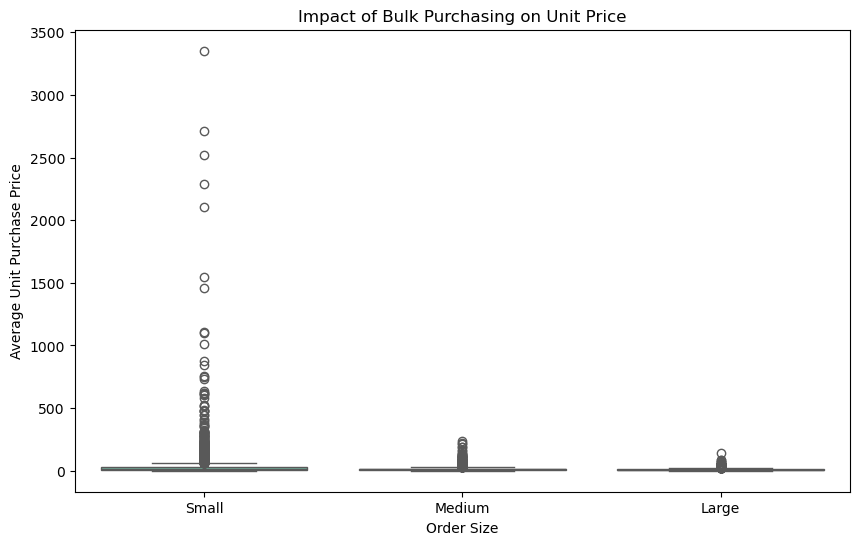

In [34]:
# box plot — order size vs unit price
# agar Large orders mein price kam ho → bulk discount confirm
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

### Bulk Purchase Pricing Insights

* **Bulk Purchasing Advantage:** Vendors placing **large orders** receive the lowest unit price (**$10.78 per unit**), which can lead to higher profit margins if inventory is managed efficiently.

* **Price Difference Between Order Sizes:** There is a significant price gap between **small and large orders**, with approximately **72% reduction in unit cost** for bulk purchases.

* **Business Implication:** This indicates that **bulk pricing strategies effectively encourage vendors to purchase larger volumes**, resulting in higher overall sales volume even though the revenue per unit is lower.


**WHICH VENDORS AHVE LOW INVENTORY TURNOVER, INDICATION EXNESS STOCK AND SLOW-MOVING PRODUCTS**

In [35]:
# ── 17. Stock Turnover < 1 — Slow Moving Vendors ────────────────────────────
# StockTurnover < 1 matlab: jitna kharida usse kam bika → stock pada raha
# ye vendors slow-moving inventory ke risk mein hain
df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean() \
    .sort_values('StockTurnover', ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


**HOW MUCH CAPITAL IS LOCKED IS UNSOLD INVENTORY PER VENDOR AND WHICH VENDORS CONTRIBUTE THE MOST TO IT?**

In [36]:
# ── 18. Unsold Inventory Value ───────────────────────────────────────────────
# kitna capital unsold stock mein locked hai?
# formula: (purchased qty - sold qty) * purchase price per unit
df['UnsoldInventoryValue'] = (
    df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']
) * df['PurchasePrice']

print('Total Unsold Capital:', format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital: 2.71M


In [37]:
# vendor wise unsold inventory value aggregate karo
# top 10 vendors jinka sabse zyada capital locked hai
inventory_value_per_vendor = df.groupby("VendorName")['UnsoldInventoryValue'].sum().reset_index()
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue", ascending=False
)
inventory_value_per_vendor['UnsoldInventoryValue'] = (
    inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


**WHAT IS THE 95% CONFIDENCE INTERVALS FOR PROFIT MARGINS OF TOP-PERFORMING AND LOW-PERFORMING VENDORS**

In [38]:
# ── 19. Hypothesis Testing — T-Test Setup ────────────────────────────────────
# top vendors = TotalSalesDollars ke top 75th percentile wale
# low vendors = TotalSalesDollars ke bottom 25th percentile wale
top_thresold = df["TotalSalesDollars"].quantile(0.75)
low_thresold = df["TotalSalesDollars"].quantile(0.25)

In [39]:
# dono groups ka profit margin nikalo
top_vendors = df[df["TotalSalesDollars"] >= top_thresold]['ProfitMargin'].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_thresold]['ProfitMargin'].dropna()

In [40]:
low_vendors

5631     4.111764
5652     6.145626
5701    12.007271
5704     1.677308
5724     7.239599
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: ProfitMargin, Length: 2141, dtype: float64

In [41]:
# ── 20. Confidence Interval Function ─────────────────────────────────────────
# 95% CI calculate karta hai
# formula: mean ± (t_critical * standard_error)
# CI batata hai ki population mean 95% probability se is range mein hoga
def confidence_intervel(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # standard error of mean
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


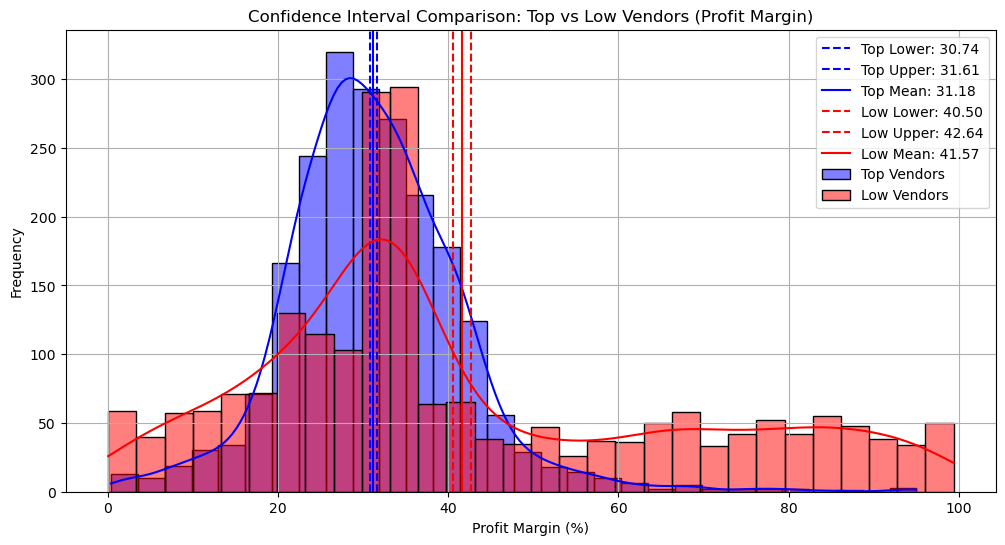

In [42]:
# top vs low vendors ka 95% CI nikalo aur plot karo
top_mean, top_lower, top_upper = confidence_intervel(top_vendors)
low_mean, low_lower, low_upper = confidence_intervel(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# top vendors distribution
sns.histplot(top_vendors, kde=True, color='blue', bins=30, alpha=0.5, label='Top Vendors')
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# low vendors distribution
sns.histplot(low_vendors, kde=True, color='red', bins=30, alpha=0.5, label='Low Vendors')
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

plt.title("Confidence Interval Comparison: Top vs Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

### Vendor Performance & Profitability Insights

* **Confidence Interval Comparison:** The confidence interval for **low-performing vendors (40.48% – 42.62%)** is significantly higher than that of **top-performing vendors (30.74% – 31.61%)**.

* **Profit Margin Observation:** This suggests that vendors with **lower sales volumes often maintain higher profit margins**, possibly due to premium pricing strategies or lower operational costs.

* **Implications for High-Performing Vendors:** To improve profitability, high-performing vendors could explore **selective price adjustments, cost optimization, or product bundling strategies**.

* **Implications for Low-Performing Vendors:** Despite higher margins, their **lower sales volume may indicate the need for improved marketing efforts, competitive pricing, or stronger distribution strategies**.


### Q. Is There a Significant difference in profit margins between top-performing and low performing vendors ?

* Hypothesis

* H0 (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

* H1 (Alternative Hypothesis): The mean profit margins of top-performing an low-performing vendors are significantly different.




In [43]:
# ── 21. Hypothesis Testing — Two Sample T-Test ───────────────────────────────
# H0: top aur low vendors ka mean profit margin same hai
# H1: dono ka mean profit margin significantly different hai
#
# Welch's T-Test use kiya (equal_var=False) kyunki dono groups ka
# sample size aur variance different ho sakta hai
# p-value < 0.05 → H0 reject karo
top_thresold = df["TotalSalesDollars"].quantile(0.75)
low_thresold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_thresold]['ProfitMargin'].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_thresold]['ProfitMargin'].dropna()

t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

print(f"T-Statistics: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: Top aur Low vendors ke profit margins mein significant difference hai.")
else:
    print("Fail to Reject H0: Koi significant difference nahi.")

T-Statistics: -17.6695, P-Value: 0.0000
Reject H0: Top aur Low vendors ke profit margins mein significant difference hai.


In [46]:
df.to_csv('vendor_sales_summary.csv', index=False)

AttributeError: 'list' object has no attribute 'to_csv'